In [4]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write("KGAT_f22103ca7377b0c06cc5e213b239f80b")

!pip install -q kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Telco Customer Churn
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -q telco-customer-churn.zip -d telco_data

# E-Commerce Customer Churn
!kaggle datasets download -d ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
!unzip -q ecommerce-customer-churn-analysis-and-prediction.zip -d ecommerce_data

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)


'unzip' is not recognized as an internal or external command,
operable program or batch file.


Dataset URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
License(s): CC-BY-NC-SA-4.0
ecommerce-customer-churn-analysis-and-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import os

print("Telco folder:", os.listdir("telco_data"))
print("E-commerce folder:", os.listdir("ecommerce_data"))

Telco folder: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
E-commerce folder: ['E Commerce Dataset.xlsx']


In [7]:
import pandas as pd

xls = pd.ExcelFile("ecommerce_data/E Commerce Dataset.xlsx")
print(xls.sheet_names)

['Data Dict', 'E Comm']


In [8]:
ecom_df = pd.read_excel("ecommerce_data/E Commerce Dataset.xlsx", sheet_name="E Comm")
ecom_df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [9]:
telco_df = pd.read_csv("telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [10]:
# --- E-commerce cleaning ---
ecom_clean = ecom_df.drop(columns=["CustomerID"])

numeric_cols_with_nulls = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder",
]
for col in numeric_cols_with_nulls:
    ecom_clean[col] = ecom_clean[col].fillna(ecom_clean[col].median())

ecom_clean["PreferredLoginDevice"] = ecom_clean["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
ecom_clean["PreferredPaymentMode"] = ecom_clean["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
ecom_clean["PreferedOrderCat"] = ecom_clean["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

print(ecom_clean.isnull().sum().sum(), "nulls remaining")
print(f"Churn rate: {ecom_clean['Churn'].mean():.2%}")

# --- Telco cleaning ---
telco_clean = telco_df.drop(columns=["customerID"])
telco_clean["TotalCharges"] = pd.to_numeric(telco_clean["TotalCharges"], errors="coerce").fillna(0)
telco_clean["Churn"] = telco_clean["Churn"].map({"Yes": 1, "No": 0})

print(telco_clean.isnull().sum().sum(), "nulls remaining")
print(f"Churn rate: {telco_clean['Churn'].mean():.2%}")

0 nulls remaining
Churn rate: 16.84%
0 nulls remaining
Churn rate: 26.54%


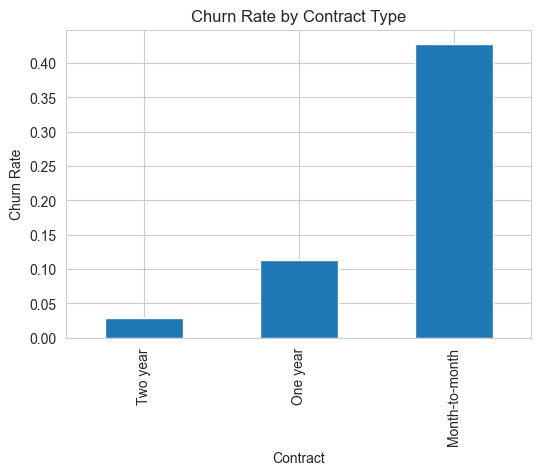

C:\Users\HP\AppData\Local\Temp\ipykernel_27120\2798757818.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  telco_clean.groupby("tenure_bucket")["Churn"].mean().plot(kind="bar", color="coral")


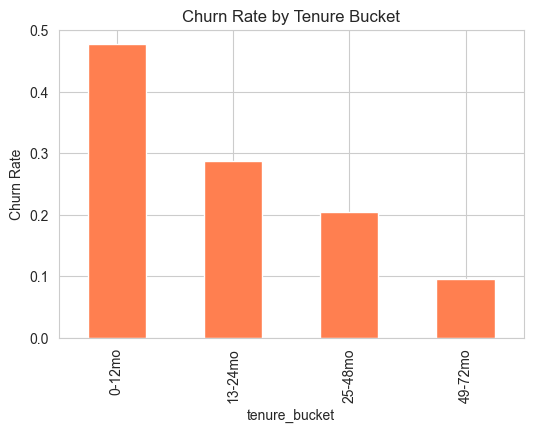

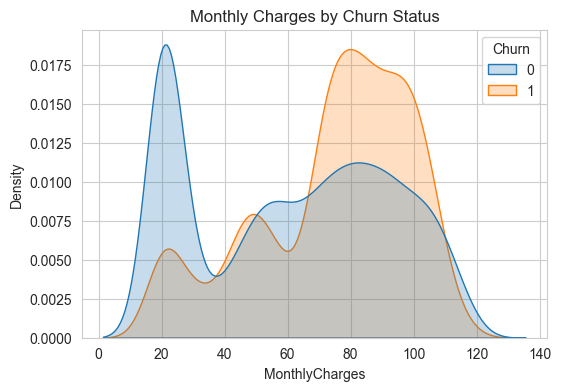

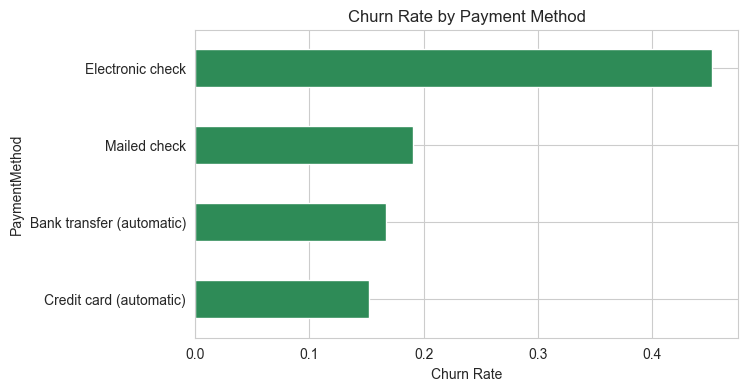

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Churn by contract type
plt.figure(figsize=(6,4))
telco_clean.groupby("Contract")["Churn"].mean().sort_values().plot(kind="bar")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Contract Type"); plt.show()

# Churn by tenure bucket
telco_clean["tenure_bucket"] = pd.cut(telco_clean["tenure"], bins=[0,12,24,48,72],
                                        labels=["0-12mo","13-24mo","25-48mo","49-72mo"])
plt.figure(figsize=(6,4))
telco_clean.groupby("tenure_bucket")["Churn"].mean().plot(kind="bar", color="coral")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Tenure Bucket"); plt.show()

# Monthly charges distribution by churn
plt.figure(figsize=(6,4))
sns.kdeplot(data=telco_clean, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False)
plt.title("Monthly Charges by Churn Status"); plt.show()

# Churn by payment method
plt.figure(figsize=(7,4))
telco_clean.groupby("PaymentMethod")["Churn"].mean().sort_values().plot(kind="barh", color="seagreen")
plt.xlabel("Churn Rate"); plt.title("Churn Rate by Payment Method"); plt.show()

<Axes: xlabel='tenure_bucket'>

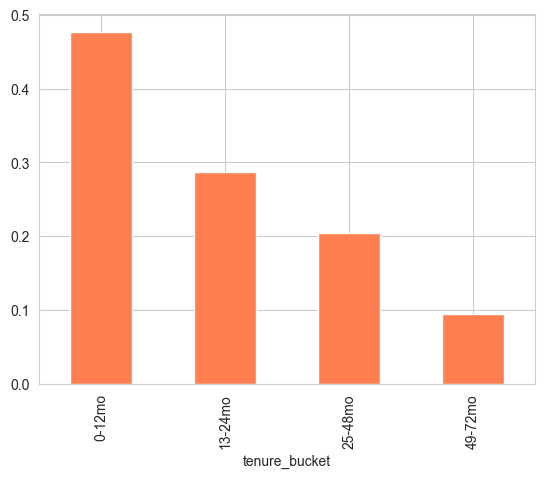

In [12]:
telco_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="coral")

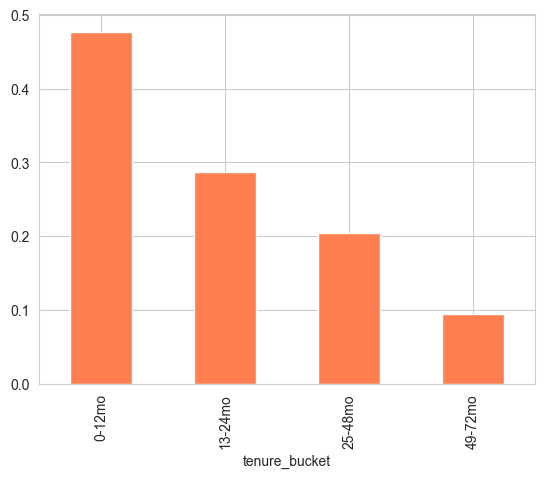

In [13]:
telco_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="coral");

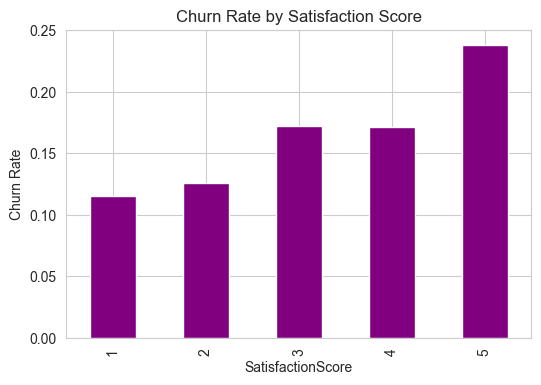

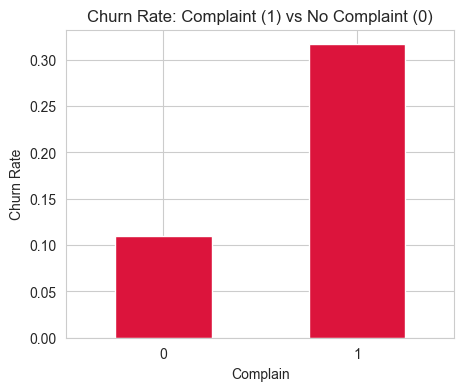

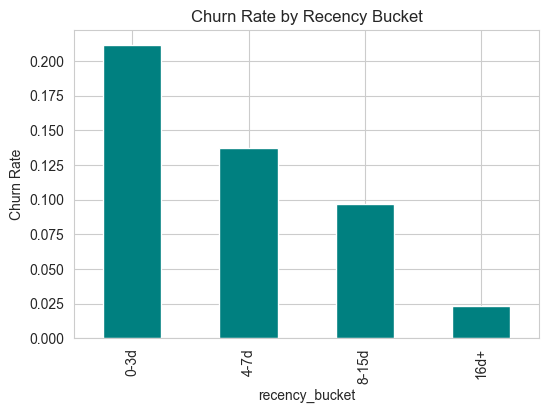

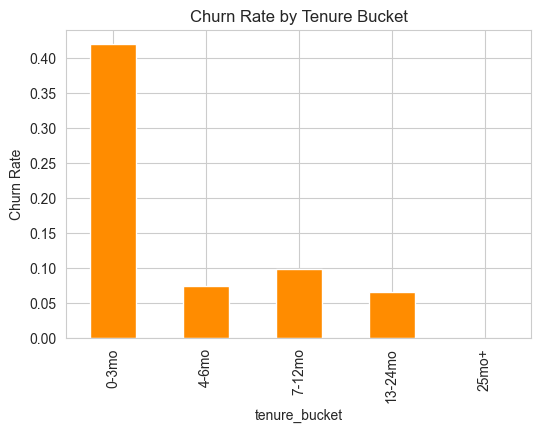

In [14]:
plt.figure(figsize=(6,4))
ecom_clean.groupby("SatisfactionScore")["Churn"].mean().plot(kind="bar", color="purple")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Satisfaction Score"); plt.show()

plt.figure(figsize=(5,4))
ecom_clean.groupby("Complain")["Churn"].mean().plot(kind="bar", color="crimson")
plt.ylabel("Churn Rate"); plt.title("Churn Rate: Complaint (1) vs No Complaint (0)"); plt.xticks(rotation=0); plt.show()

ecom_clean["recency_bucket"] = pd.cut(ecom_clean["DaySinceLastOrder"], bins=[-1,3,7,15,50],
                                        labels=["0-3d","4-7d","8-15d","16d+"])
plt.figure(figsize=(6,4))
ecom_clean.groupby("recency_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="teal")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Recency Bucket"); plt.show()

ecom_clean["tenure_bucket"] = pd.cut(ecom_clean["Tenure"], bins=[-1,3,6,12,24,60],
                                       labels=["0-3mo","4-6mo","7-12mo","13-24mo","25mo+"])
plt.figure(figsize=(6,4))
ecom_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="darkorange")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Tenure Bucket"); plt.show()

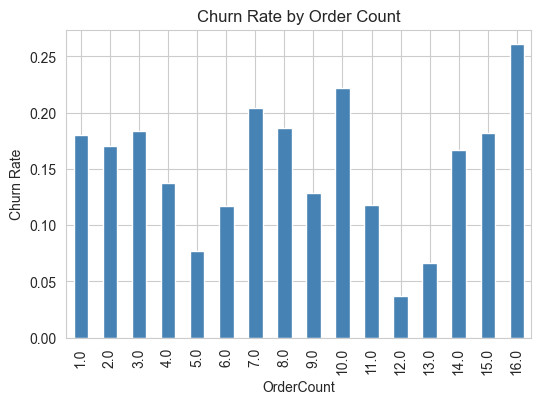

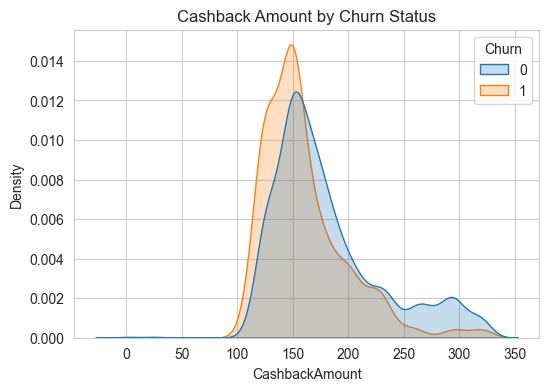

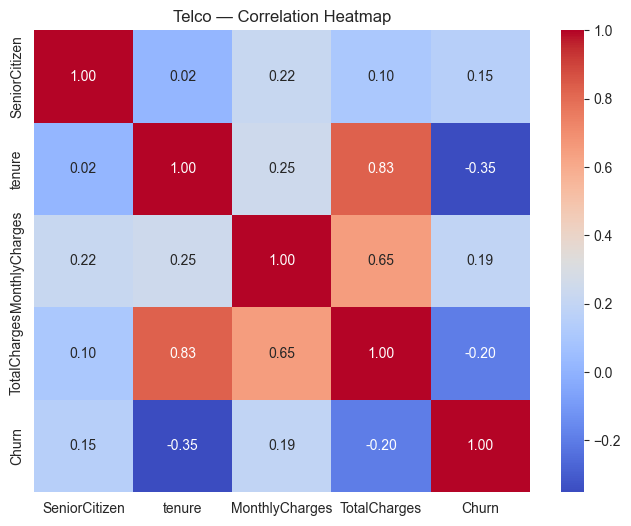

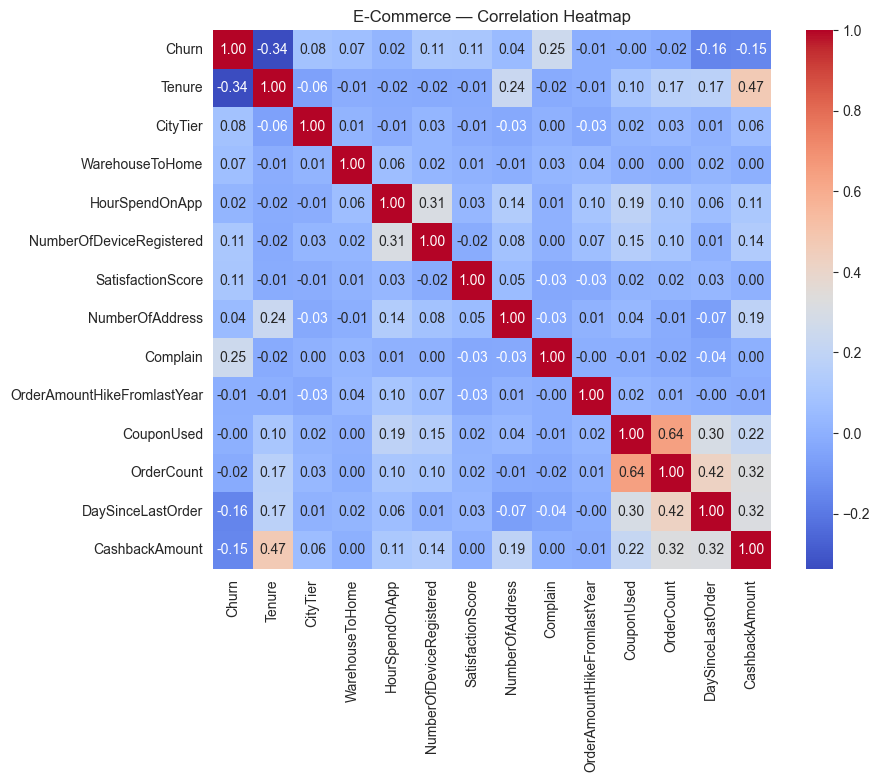

In [15]:
# Order frequency
plt.figure(figsize=(6,4))
ecom_clean.groupby("OrderCount")["Churn"].mean().plot(kind="bar", color="steelblue")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Order Count"); plt.show()

# Pricing signal (e-commerce)
plt.figure(figsize=(6,4))
sns.kdeplot(data=ecom_clean, x="CashbackAmount", hue="Churn", fill=True, common_norm=False)
plt.title("Cashback Amount by Churn Status"); plt.show()

# Correlation heatmaps
plt.figure(figsize=(8,6))
sns.heatmap(telco_clean.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Telco — Correlation Heatmap"); plt.show()

plt.figure(figsize=(9,7))
sns.heatmap(ecom_clean.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("E-Commerce — Correlation Heatmap"); plt.show()

In [16]:
import pandas as pd

# --- 1. Dataset comparison, computed not hardcoded ---
comparison = pd.DataFrame({
    "Telco": [len(telco_clean), telco_clean["Churn"].mean(), telco_clean.shape[1]],
    "E-Commerce": [len(ecom_clean), ecom_clean["Churn"].mean(), ecom_clean.shape[1]],
}, index=["Rows", "Churn Rate", "Num Features"])
print(comparison)

# --- 2. Rank numeric features by correlation with churn (per dataset) ---
telco_corr = telco_clean.select_dtypes(include="number").corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
ecom_corr = ecom_clean.select_dtypes(include="number").corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

print("\nTelco — features ranked by correlation with churn:")
print(telco_corr)
print("\nE-Commerce — features ranked by correlation with churn:")
print(ecom_corr)

# --- 3. Rank categorical features by churn-rate spread (max - min across categories) ---
def categorical_churn_spread(df, cat_cols):
    spreads = {}
    for col in cat_cols:
        rates = df.groupby(col)["Churn"].mean()
        spreads[col] = rates.max() - rates.min()
    return pd.Series(spreads).sort_values(ascending=False)

telco_cat_cols = telco_clean.select_dtypes(include="object").columns.tolist()
ecom_cat_cols = ecom_clean.select_dtypes(include="object").columns.tolist()

print("\nTelco — categorical features ranked by churn-rate spread:")
print(categorical_churn_spread(telco_clean, telco_cat_cols))
print("\nE-Commerce — categorical features ranked by churn-rate spread:")
print(categorical_churn_spread(ecom_clean, ecom_cat_cols))

# --- 4. Save handoff-ready CSVs with engineered buckets already included ---
telco_clean.to_csv("telco_cleaned_final.csv", index=False)
ecom_clean.to_csv("ecommerce_cleaned_final.csv", index=False)
print("\nSaved: telco_cleaned_final.csv, ecommerce_cleaned_final.csv")

                   Telco   E-Commerce
Rows          7043.00000  5630.000000
Churn Rate       0.26537     0.168384
Num Features    21.00000    21.000000

Telco — features ranked by correlation with churn:
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn, dtype: float64

E-Commerce — features ranked by correlation with churn:
Tenure                        -0.337831
Complain                       0.250188
DaySinceLastOrder             -0.155871
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.069544
NumberOfAddress                0.043931
OrderCount                    -0.024038
HourSpendOnApp                 0.018816
OrderAmountHikeFromlastYear   -0.007075
CouponUsed                    -0.001430
Name: Churn, dtype: float64

Telco — categorical features ranked by churn-rate spre

# Part 2: Advanced Feature Engineering & Modeling Pipeline (Updated with Tuning & CV)

The following cells implement the revised ML pipeline including duplicate removal, K-Fold CV, Hyperparameter Tuning, and Top 10 Feature Selection.

In [ ]:
import pandas as pd
import numpy as np
import os

def load_and_prep_telco(data_path="telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv"):
    df = pd.read_csv(data_path)
    
    # Remove duplicate rows to prevent data leakage between train/test splits
    df = df.drop_duplicates()
    

    df = df.drop(columns=["customerID"])
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
    df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0,12,24,48,72], labels=["0-12mo","13-24mo","25-48mo","49-72mo"])
    
    # Advanced Feature Engineering for Telco
    # Usage decline proxy / Pricing features
    # ratio of total charges to tenure (proxy for average monthly charge). Handle div by zero if tenure is 0.
    df["AvgCharge_vs_Monthly"] = np.where(df["tenure"] > 0, (df["TotalCharges"] / df["tenure"]) - df["MonthlyCharges"], 0)
    df["high_monthly_charge"] = (df["MonthlyCharges"] > df["MonthlyCharges"].quantile(0.75)).astype(int)
    
    # Contract type & Customer support interactions
    df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
    df["has_tech_support"] = (df["TechSupport"] == "Yes").astype(int)
    
    # Interactions
    df["high_risk_contract_no_support"] = (df["is_month_to_month"] & (df["has_tech_support"] == 0)).astype(int)
    
    # Create simple categories for prediction UI later
    df["Support_Interactions_Level"] = df["TechSupport"].replace({"No": "Low", "No internet service": "None", "Yes": "High"})
    
    return df

def load_and_prep_ecom(data_path="ecommerce_data/E Commerce Dataset.xlsx"):
    df = pd.read_excel(data_path, sheet_name="E Comm")
    
    # Remove duplicate rows to prevent data leakage between train/test splits
    df = df.drop_duplicates()
    
    #prep
    df = df.drop(columns=["CustomerID"])
    numeric_cols_with_nulls = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder"]
    for col in numeric_cols_with_nulls:
        df[col] = df[col].fillna(df[col].median())
        
    df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
    df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
    df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})
    
    df["recency_bucket"] = pd.cut(df["DaySinceLastOrder"], bins=[-1,3,7,15,50], labels=["0-3d","4-7d","8-15d","16d+"])
    df["tenure_bucket"] = pd.cut(df["Tenure"], bins=[-1,3,6,12,24,60], labels=["0-3mo","4-6mo","7-12mo","13-24mo","25mo+"])
    
    # Advanced Feature Engineering for E-Commerce
    # Usage / Recency
    df["frequent_shopper"] = (df["OrderCount"] > df["OrderCount"].median()).astype(int)
    df["inactivity_flag"] = (df["DaySinceLastOrder"] > 15).astype(int)
    
    # Satisfaction and Complaints
    df["low_satisfaction_flag"] = (df["SatisfactionScore"] <= 2).astype(int)
    df["high_support_contact_flag"] = df["Complain"] # already 0/1
    df["unhappy_and_complained"] = (df["low_satisfaction_flag"] & df["high_support_contact_flag"]).astype(int)
    
    # Pricing
    df["high_cashback"] = (df["CashbackAmount"] > df["CashbackAmount"].quantile(0.75)).astype(int)
    
    return df

if __name__ == "__main__":
    t_df = load_and_prep_telco()
    print("Telco prep shape:", t_df.shape)
    e_df = load_and_prep_ecom()
    print("E-com prep shape:", e_df.shape)


Telco prep shape: (7043, 27)
E-com prep shape: (5630, 27)


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shap

def build_and_evaluate(df, target_col, name, output_dir="models", max_features=5):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n{'='*50}\nProcessing {name} Dataset\n{'='*50}")
    
    churn_count = df[target_col].sum()
    total = len(df)
    print(f"Total samples: {total} | Churn count: {churn_count} ({churn_count/total:.2%})")
    
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Stratified K-Fold setup
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
        ]
    )
    
    scale_pos_weight = (len(y) - y.sum()) / y.sum()
    
    # ---------------------------------------------------------
    # Logistic Regression Baseline (using 5-Fold CV for metrics)
    # ---------------------------------------------------------
    print("\n[Logistic Regression Baseline - 5-Fold CV]")
    lr_roc_aucs = []
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        lr_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
        ])
        lr_pipe.fit(X_train, y_train)
        probs = lr_pipe.predict_proba(X_test)[:, 1]
        
        lr_roc_aucs.append(roc_auc_score(y_test, probs))
        
    print(f"Mean ROC-AUC: {np.mean(lr_roc_aucs):.4f}")

    # ---------------------------------------------------------
    # XGBoost with Feature Selection (5-Fold CV for metrics)
    # ---------------------------------------------------------
    print("\n[XGBoost with 5 Features - 5-Fold CV]")
    
    feature_selector = SelectFromModel(
        XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
        max_features=max_features,
        threshold=-np.inf
    )
    
    xgb_roc_aucs = []
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        xgb_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('selector', feature_selector),
            ('classifier', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))
        ])
        xgb_pipe.fit(X_train, y_train)
        probs = xgb_pipe.predict_proba(X_test)[:, 1]
        
        xgb_roc_aucs.append(roc_auc_score(y_test, probs))
        
    print(f"Mean ROC-AUC: {np.mean(xgb_roc_aucs):.4f}")
    
    # ---------------------------------------------------------
    # Final Model Training & Saving
    # ---------------------------------------------------------
    # Split for final evaluation
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('classifier', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))
    ])
    
    xgb_pipeline.fit(X_train, y_train)
    xgb_preds = xgb_pipeline.predict(X_test)
    xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]
    
    print("\n[Final XGBoost Results on Hold-Out Test Set]")
    print(f"ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")
    print(f"Precision: {precision_score(y_test, xgb_preds):.4f}")
    print(f"Recall: {recall_score(y_test, xgb_preds):.4f}")
    print(f"F1: {f1_score(y_test, xgb_preds):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, xgb_preds))
    print("\nClassification Report:")
    print(classification_report(y_test, xgb_preds))
    
    # Save Model
    joblib.dump(xgb_pipeline, os.path.join(output_dir, f"{name}_xgb_pipeline.joblib"))
    print(f"Saved {name} tuned model artifact (includes {max_features} top features limitation).")
    
    # Feature Importance Extraction
    cat_encoder = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    all_feature_names = numeric_cols + list(cat_encoder.get_feature_names_out(categorical_cols)) if len(categorical_cols) > 0 else numeric_cols
    
    # Get selected feature names
    selector_support = xgb_pipeline.named_steps['selector'].get_support()
    selected_features = np.array(all_feature_names)[selector_support]
    
    xgb_classifier = xgb_pipeline.named_steps['classifier']
    importances = xgb_classifier.feature_importances_
    
    fi_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Importance', y='Feature', color='teal')
    plt.title(f"{name} - XGBoost Feature Importances (Top {max_features} Selected)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name}_feature_importance.png"))
    plt.close()
    
    print(f"Top Features Selected for Dashboard: {list(fi_df['Feature'].values)}")

if __name__ == "__main__":
    
    
    MAX_FEATURES_DASHBOARD = 5
    
    # Telco
    telco_df = load_and_prep_telco("telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    build_and_evaluate(telco_df, target_col="Churn", name="Telco", output_dir="models", max_features=MAX_FEATURES_DASHBOARD)
    
    # E-commerce
    ecom_df = load_and_prep_ecom("ecommerce_data/E Commerce Dataset.xlsx")
    build_and_evaluate(ecom_df, target_col="Churn", name="ECommerce", output_dir="models", max_features=MAX_FEATURES_DASHBOARD)



Processing Telco Dataset
Total samples: 7043 | Churn count: 1869 (26.54%)

[Logistic Regression Baseline - 5-Fold CV]
Mean ROC-AUC: 0.8459

[XGBoost with 5 Features - 5-Fold CV]
Mean ROC-AUC: 0.8074

[Final XGBoost Results on Hold-Out Test Set]
ROC-AUC: 0.7992
Precision: 0.4758
Recall: 0.7620
F1: 0.5858

Confusion Matrix:
[[721 314]
 [ 89 285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1035
           1       0.48      0.76      0.59       374

    accuracy                           0.71      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.71      0.73      1409

Saved Telco tuned model artifact (includes 5 top features limitation).
Top Features Selected for Dashboard: ['is_month_to_month', 'Contract_One year', 'InternetService_Fiber optic', 'Contract_Two year', 'Support_Interactions_Level_Low']

Processing ECommerce Dataset
Total samples: 5630 | Churn count:

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Mean ROC-AUC: 0.9008

[XGBoost with 5 Features - 5-Fold CV]


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Mean ROC-AUC: 0.8796

[Final XGBoost Results on Hold-Out Test Set]
ROC-AUC: 0.8745
Precision: 0.4559
Recall: 0.8158
F1: 0.5849

Confusion Matrix:
[[751 185]
 [ 35 155]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       936
           1       0.46      0.82      0.58       190

    accuracy                           0.80      1126
   macro avg       0.71      0.81      0.73      1126
weighted avg       0.87      0.80      0.82      1126

Saved ECommerce tuned model artifact (includes 5 top features limitation).
Top Features Selected for Dashboard: ['Tenure', 'Complain', 'tenure_bucket_7-12mo', 'PreferedOrderCat_Laptop & Accessory', 'tenure_bucket_4-6mo']


## Final Model Performance Summary

Below are the final evaluation metrics for the XGBoost models trained on the **Top 5 features** for both datasets on the hold-out test set.

### 1. Telco Dataset Results
- **ROC-AUC:** 0.7992
- **Precision:** 0.4758
- **Recall:** 0.7620
- **F1-Score:** 0.5858

**Confusion Matrix:**
`	ext
[[721 314]
 [ 89 285]]
`
**Selected Features:** is_month_to_month, Contract_One year, InternetService_Fiber optic, Contract_Two year, Support_Interactions_Level_Low

---

### 2. E-Commerce Dataset Results
- **ROC-AUC:** 0.8745
- **Precision:** 0.4559
- **Recall:** 0.8158
- **F1-Score:** 0.5849

**Confusion Matrix:**
`	ext
[[751 185]
 [ 35 155]]
`
**Selected Features:** Tenure, Complain, 	enure_bucket_7-12mo, PreferedOrderCat_Laptop & Accessory, 	enure_bucket_4-6mo